# Fraud Transaction Analysis

This notebook contains the finalized analysis for the synthetic fraud dataset.

**Analysis included:**
1. Data loading and preparation
2. Exploratory analysis
3. Chi-square tests for categorical variables
4. Welch t-tests for numeric variables
5. ANOVA tests for country/hour-bucket differences in device and IP risk scores
6. Post-ANOVA pairwise follow-up tests
7. Random Forest model benchmark and feature importance

The practical risk-flag monitoring section was removed to keep the final notebook focused on statistical analysis and model evaluation.

In [13]:
# Import libraries
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, ttest_ind, f_oneway
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)

# File paths
DATA_PATH = Path("synthetic_fraud_dataset.xlsx")
OUTPUT_DIR = Path("fraud_final_outputs")

# Create output folder if it does not exist
OUTPUT_DIR.mkdir(exist_ok=True)

# Check dataset file exists
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Cannot find synthetic_fraud_dataset.xlsx. "
        "Please place it in the same folder as this notebook."
    )


## 1. Load and prepare the data

In [14]:

# Load dataset
df = pd.read_excel(DATA_PATH)

# Create variables used in the analysis
df["fraud_label"] = df["is_fraud"].map({0: "Non-fraud", 1: "Fraud"})
df["log_amount"] = np.log1p(df["amount"])

df["hour_bucket"] = pd.cut(
    df["hour"],
    bins=[-1, 5, 11, 17, 23],
    labels=[
        "Night (00-05)",
        "Morning (06-11)",
        "Afternoon (12-17)",
        "Evening (18-23)"
    ]
)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10000, 13)


,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud,fraud_label,log_amount,hour_bucket
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1,Fraud,8.501793,Afternoon (12-17)
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0,Non-fraud,3.892194,Evening (18-23)
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0,Non-fraud,4.926398,Afternoon (12-17)
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0,Non-fraud,4.401029,Evening (18-23)
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0,Non-fraud,4.796131,Afternoon (12-17)


In [15]:
summary = pd.DataFrame({
    'Metric': ['Transactions', 'Fraud cases', 'Non-fraud cases', 'Fraud rate'],
    'Value': [
        len(df),
        int(df['is_fraud'].sum()),
        int((df['is_fraud'] == 0).sum()),
        f"{df['is_fraud'].mean():.1%}"
    ]
})
summary

,Metric,Value
0,Transactions,10000
1,Fraud cases,500
2,Non-fraud cases,9500
3,Fraud rate,5.0%


## 2. Exploratory analysis

This section reviews the fraud rate across key categorical variables. The goal is to identify initial patterns before formal hypothesis testing.

In [16]:
def fraud_rate_summary(data, group_col):
    out = (data.groupby(group_col, observed=True)['is_fraud']
           .agg(['count', 'sum', 'mean'])
           .rename(columns={'count': 'transactions', 'sum': 'fraud_cases', 'mean': 'fraud_rate'})
           .reset_index()
           .sort_values('fraud_rate', ascending=False))
    out['fraud_rate_pct'] = out['fraud_rate'] * 100
    return out

for col in ['country', 'hour_bucket', 'transaction_type', 'merchant_category']:
    print(f'\nFraud rate by {col}')
    display(fraud_rate_summary(df, col))


Fraud rate by country


,country,transactions,fraud_cases,fraud_rate,fraud_rate_pct
2,NG,100,100,1.000000,100.000000
5,US,2050,97,0.047317,4.731707
4,UK,1965,85,0.043257,4.325700
3,TR,1928,75,0.038900,3.890041
1,FR,2027,74,0.036507,3.650715
0,DE,1930,69,0.035751,3.575130



Fraud rate by hour_bucket


,hour_bucket,transactions,fraud_cases,fraud_rate,fraud_rate_pct
0,Night (00-05),193,193,1.000000,100.000000
1,Morning (06-11),3270,107,0.032722,3.272171
3,Evening (18-23),3218,103,0.032007,3.200746
2,Afternoon (12-17),3319,97,0.029226,2.922567



Fraud rate by transaction_type


,transaction_type,transactions,fraud_cases,fraud_rate,fraud_rate_pct
0,ATM,2529,138,0.054567,5.456702
1,Online,2397,126,0.052566,5.256571
3,QR,2506,120,0.047885,4.788508
2,POS,2568,116,0.045171,4.517134



Fraud rate by merchant_category


,merchant_category,transactions,fraud_cases,fraud_rate,fraud_rate_pct
0,Clothing,1982,109,0.054995,5.499495
4,Travel,2015,106,0.052605,5.260546
1,Electronics,2007,98,0.048829,4.882910
3,Grocery,1973,95,0.048150,4.815003
2,Food,2023,92,0.045477,4.547701


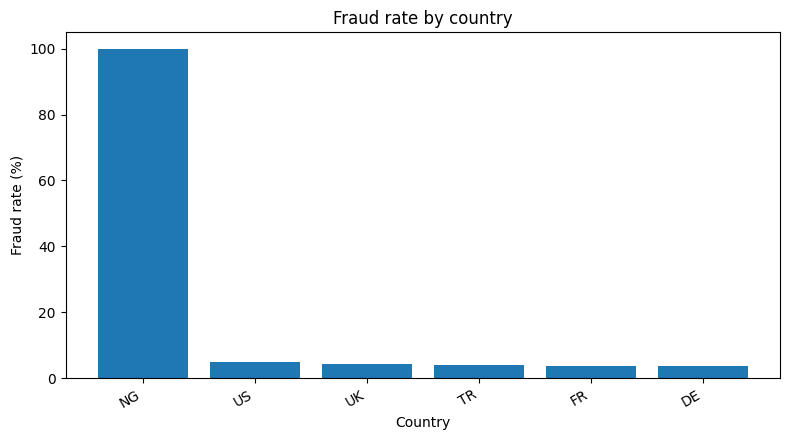

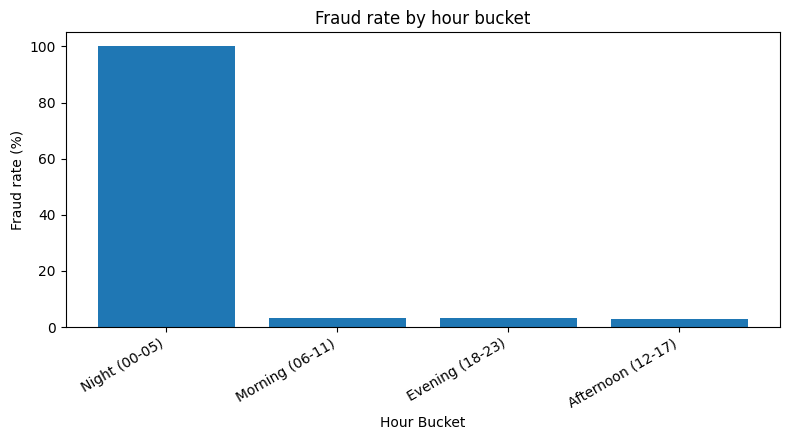

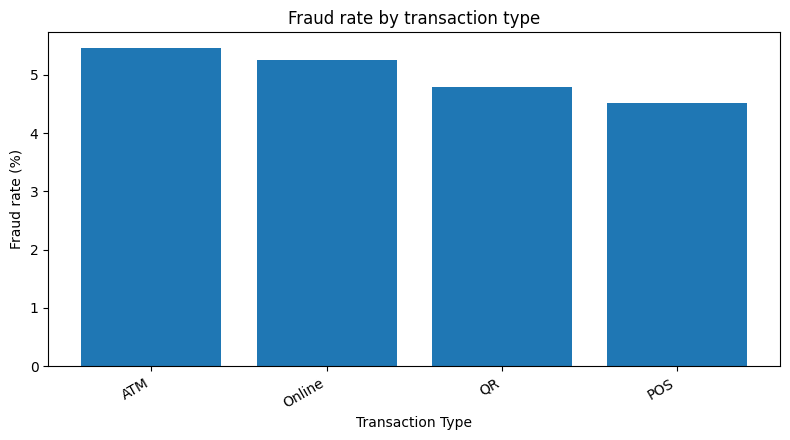

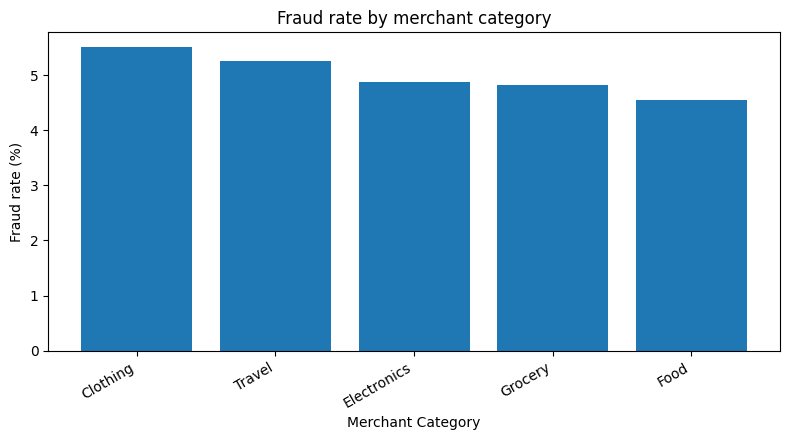

In [17]:
# Save categorical fraud-rate charts
for col, title in [
    ('country', 'Fraud rate by country'),
    ('hour_bucket', 'Fraud rate by hour bucket'),
    ('transaction_type', 'Fraud rate by transaction type'),
    ('merchant_category', 'Fraud rate by merchant category')
]:
    temp = fraud_rate_summary(df, col)
    plt.figure(figsize=(8, 4.5))
    plt.bar(temp[col].astype(str), temp['fraud_rate_pct'])
    plt.title(title)
    plt.ylabel('Fraud rate (%)')
    plt.xlabel(col.replace('_', ' ').title())
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{col}_fraud_rate.png', dpi=200)
    plt.show()

## 3. Chi-square tests

**Purpose:** Chi-square tests check whether fraud status is associated with categorical variables.

**Null hypothesis (H0):** Fraud status is independent of the category.

**Alternative hypothesis (H1):** Fraud status is associated with the category.

In [18]:
categorical_vars = ['transaction_type', 'merchant_category', 'country', 'hour_bucket']
chi_square_results = []

for col in categorical_vars:
    contingency = pd.crosstab(df[col], df['is_fraud'])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    chi_square_results.append({
        'Variable': col,
        'Test': 'Chi-square test',
        'Chi-square statistic': chi2,
        'Degrees of freedom': dof,
        'p-value': p_value,
        'Significant at 5%': p_value < 0.05
    })

chi_square_df = pd.DataFrame(chi_square_results).sort_values('p-value')
chi_square_df.to_csv(OUTPUT_DIR / 'chi_square_results.csv', index=False)
chi_square_df

,Variable,Test,Chi-square statistic,Degrees of freedom,p-value,Significant at 5%
2,country,Chi-square test,1923.210542,5,0.000000,True
3,hour_bucket,Chi-square test,3739.639609,3,0.000000,True
0,transaction_type,Chi-square test,2.939215,3,0.401092,False
1,merchant_category,Chi-square test,2.400380,4,0.662559,False


**Interpretation:** Country and hour bucket are significantly associated with fraud status. Transaction type and merchant category are weaker indicators in this dataset.

## 4. Welch two-sample t-tests

**Purpose:** The t-tests compare average numeric values between fraud and non-fraud transactions.

**Null hypothesis (H0):** The mean value is the same for fraud and non-fraud transactions.

**Alternative hypothesis (H1):** The mean value is different for fraud and non-fraud transactions.

In [19]:
numeric_vars = ['amount', 'log_amount', 'device_risk_score', 'ip_risk_score']
ttest_results = []

fraud_df = df[df['is_fraud'] == 1]
nonfraud_df = df[df['is_fraud'] == 0]

for col in numeric_vars:
    stat, p_value = ttest_ind(fraud_df[col], nonfraud_df[col], equal_var=False)
    ttest_results.append({
        'Variable': col,
        'Test': 'Welch two-sample t-test',
        'Fraud mean': fraud_df[col].mean(),
        'Non-fraud mean': nonfraud_df[col].mean(),
        'Difference': fraud_df[col].mean() - nonfraud_df[col].mean(),
        't-statistic': stat,
        'p-value': p_value,
        'Significant at 5%': p_value < 0.05
    })

ttest_df = pd.DataFrame(ttest_results).sort_values('p-value')
ttest_df.to_csv(OUTPUT_DIR / 'welch_ttest_results.csv', index=False)
ttest_df

,Variable,Test,Fraud mean,Non-fraud mean,Difference,t-statistic,p-value,Significant at 5%
2,device_risk_score,Welch two-sample t-test,0.857951,0.148290,0.709661,177.777491,0.000000e+00,True
3,ip_risk_score,Welch two-sample t-test,0.851770,0.149558,0.702212,175.855965,0.000000e+00,True
0,amount,Welch two-sample t-test,1657.577984,100.277751,1557.300232,19.143834,1.165939e-61,True
1,log_amount,Welch two-sample t-test,6.130736,4.399628,1.731108,17.099744,4.381833e-52,True


<Figure size 700x400 with 0 Axes>

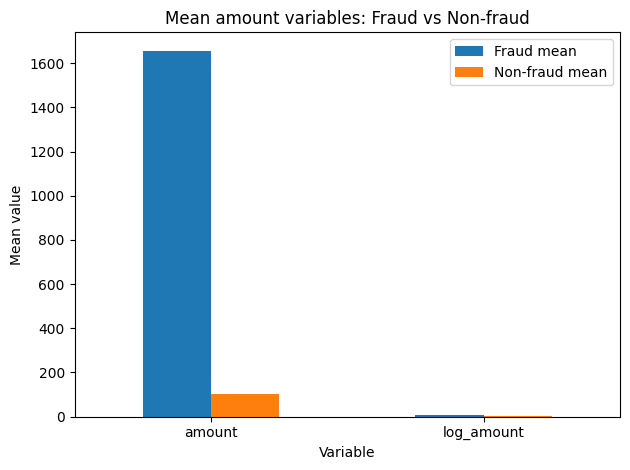

<Figure size 700x400 with 0 Axes>

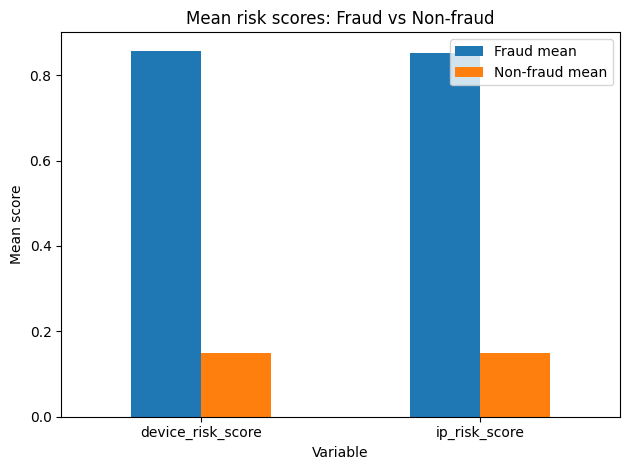

In [20]:
# T-test visual summaries
mean_table = ttest_df.set_index('Variable')[['Fraud mean', 'Non-fraud mean']]

plt.figure(figsize=(7, 4))
mean_table.loc[['amount', 'log_amount']].plot(kind='bar')
plt.title('Mean amount variables: Fraud vs Non-fraud')
plt.ylabel('Mean value')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ttest_amount_means.png', dpi=200)
plt.show()

plt.figure(figsize=(7, 4))
mean_table.loc[['device_risk_score', 'ip_risk_score']].plot(kind='bar')
plt.title('Mean risk scores: Fraud vs Non-fraud')
plt.ylabel('Mean score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ttest_risk_score_means.png', dpi=200)
plt.show()

**Interpretation:** Fraud transactions have significantly higher mean transaction amount, log amount, device risk score and IP risk score. This means these variables help separate fraud transactions from normal transactions.

## 5. ANOVA tests

**Purpose:** ANOVA tests whether the average device/IP risk score differs across multiple country or hour-bucket groups.

**Null hypothesis (H0):** The mean risk score is the same across all groups.

**Alternative hypothesis (H1):** At least one group has a different mean risk score.

In [21]:
anova_tests = []
for group_col in ['country', 'hour_bucket']:
    for score_col in ['device_risk_score', 'ip_risk_score']:
        groups = [g[score_col].dropna().values for _, g in df.groupby(group_col, observed=True)]
        f_stat, p_value = f_oneway(*groups)
        anova_tests.append({
            'Group variable': group_col,
            'Numeric variable': score_col,
            'Test': 'One-way ANOVA',
            'F-statistic': f_stat,
            'p-value': p_value,
            'Significant at 5%': p_value < 0.05
        })

anova_df = pd.DataFrame(anova_tests).sort_values('p-value')
anova_df.to_csv(OUTPUT_DIR / 'anova_results.csv', index=False)
anova_df

,Group variable,Numeric variable,Test,F-statistic,p-value,Significant at 5%
0,country,device_risk_score,One-way ANOVA,322.983423,0.0,True
1,country,ip_risk_score,One-way ANOVA,343.593907,0.0,True
2,hour_bucket,device_risk_score,One-way ANOVA,1307.944819,0.0,True
3,hour_bucket,ip_risk_score,One-way ANOVA,1385.383864,0.0,True


In [22]:
# Mean risk scores by country and hour bucket
country_risk_means = df.groupby('country')[['device_risk_score', 'ip_risk_score']].mean().sort_values('ip_risk_score', ascending=False)
hour_risk_means = df.groupby('hour_bucket', observed=True)[['device_risk_score', 'ip_risk_score']].mean()

display(country_risk_means)
display(hour_risk_means)

country_risk_means.to_csv(OUTPUT_DIR / 'country_risk_score_means.csv')
hour_risk_means.to_csv(OUTPUT_DIR / 'hour_bucket_risk_score_means.csv')

,device_risk_score,ip_risk_score
country,,
NG,0.841197,0.853669
US,0.182631,0.181730
UK,0.177525,0.181448
FR,0.172683,0.176897
TR,0.177301,0.176067
DE,0.175395,0.173162


,device_risk_score,ip_risk_score
hour_bucket,,
Night (00-05),0.854957,0.863597
Morning (06-11),0.169227,0.171455
Afternoon (12-17),0.169472,0.172532
Evening (18-23),0.173050,0.169895


**Interpretation:** ANOVA shows that mean device/IP risk scores differ significantly across countries and hour buckets. However, ANOVA only tells us that at least one group is different. It does not tell us exactly which group is different, so post-ANOVA follow-up tests are needed.

## 6. Post-ANOVA pairwise follow-up tests

Because the ANOVA results are significant, pairwise Welch t-tests with Holm correction are used to identify which groups are driving the differences.

In [35]:
# Targeted pairwise Welch t-tests after ANOVA
# Purpose: compare the main high-risk group against each other group

from scipy.stats import ttest_ind
import pandas as pd

targeted_pairwise_results = []

def targeted_pairwise_ttest(data, group_col, value_col, target_group):
    data_temp = data.copy()
    data_temp[group_col] = data_temp[group_col].astype(str)

    groups = sorted(data_temp[group_col].dropna().unique())

    for comparison_group in groups:
        if comparison_group == target_group:
            continue

        target_values = data_temp.loc[
            data_temp[group_col] == target_group, value_col
        ].dropna()

        comparison_values = data_temp.loc[
            data_temp[group_col] == comparison_group, value_col
        ].dropna()

        stat, p = ttest_ind(
            target_values,
            comparison_values,
            equal_var=False
        )

        targeted_pairwise_results.append({
            "Group variable": group_col,
            "Numeric variable": value_col,
            "Target group": target_group,
            "Comparison group": comparison_group,
            "Target group mean": target_values.mean(),
            "Comparison group mean": comparison_values.mean(),
            "Mean difference": target_values.mean() - comparison_values.mean(),
            "T-statistic": stat,
            "P-value": p,
            "Significant at 5%": p < 0.05
        })


# Country: NG vs each other country
for score_col in ["device_risk_score", "ip_risk_score"]:
    targeted_pairwise_ttest(
        df,
        group_col="country",
        value_col=score_col,
        target_group="NG"
    )


# Hour bucket: Night vs each other hour bucket
for score_col in ["device_risk_score", "ip_risk_score"]:
    targeted_pairwise_ttest(
        df,
        group_col="hour_bucket",
        value_col=score_col,
        target_group="Night (00-05)"
    )


targeted_pairwise_df = pd.DataFrame(targeted_pairwise_results)

targeted_pairwise_df.to_csv(
    OUTPUT_DIR / "targeted_pairwise_welch_ttests.csv",
    index=False
)

targeted_pairwise_df.sort_values(
    ["Group variable", "Numeric variable", "P-value"]
)

,Group variable,Numeric variable,Target group,Comparison group,Target group mean,Comparison group mean,Mean difference,T-statistic,P-value,Significant at 5%
4,country,device_risk_score,NG,US,0.841197,0.182631,0.658565,71.630694,7.570391e-116,True
3,country,device_risk_score,NG,UK,0.841197,0.177525,0.663671,72.498752,3.696345e-115,True
2,country,device_risk_score,NG,TR,0.841197,0.177301,0.663896,72.772366,2.919352e-114,True
0,country,device_risk_score,NG,DE,0.841197,0.175395,0.665801,73.285128,2.505145e-113,True
1,country,device_risk_score,NG,FR,0.841197,0.172683,0.668514,73.851687,1.313144e-112,True
9,country,ip_risk_score,NG,US,0.853669,0.181730,0.671939,73.529150,4.440716e-117,True
8,country,ip_risk_score,NG,UK,0.853669,0.181448,0.672221,73.715598,1.601612e-116,True
7,country,ip_risk_score,NG,TR,0.853669,0.176067,0.677602,74.915067,8.767992e-115,True
5,country,ip_risk_score,NG,DE,0.853669,0.173162,0.680507,75.537025,5.890436e-114,True
6,country,ip_risk_score,NG,FR,0.853669,0.176897,0.676772,75.139528,1.400690e-113,True


In [32]:
# Targeted Welch t-tests for the main groups identified by the analysis

ng_vs_others = []

for score_col in ["device_risk_score", "ip_risk_score"]:
    ng = df.loc[df["country"] == "NG", score_col].dropna()
    others = df.loc[df["country"] != "NG", score_col].dropna()

    stat, p = ttest_ind(ng, others, equal_var=False)

    ng_vs_others.append({
        "Comparison": "NG vs all other countries",
        "Numeric variable": score_col,
        "NG mean": ng.mean(),
        "Other countries mean": others.mean(),
        "Mean difference": ng.mean() - others.mean(),
        "T-statistic": stat,
        "P-value": p,
        "Significant at 5%": p < 0.05
    })


night_vs_others = []

for score_col in ["device_risk_score", "ip_risk_score"]:
    night = df.loc[df["hour_bucket"].astype(str) == "Night (00-05)", score_col].dropna()
    others = df.loc[df["hour_bucket"].astype(str) != "Night (00-05)", score_col].dropna()

    stat, p = ttest_ind(night, others, equal_var=False)

    night_vs_others.append({
        "Comparison": "Night vs all other hour buckets",
        "Numeric variable": score_col,
        "Night mean": night.mean(),
        "Other hour buckets mean": others.mean(),
        "Mean difference": night.mean() - others.mean(),
        "T-statistic": stat,
        "P-value": p,
        "Significant at 5%": p < 0.05
    })


targeted_followup_df = pd.DataFrame(ng_vs_others + night_vs_others)

targeted_followup_df.to_csv(
    OUTPUT_DIR / "targeted_post_anova_followup.csv",
    index=False
)

targeted_followup_df

,Comparison,Numeric variable,NG mean,Other countries mean,Mean difference,T-statistic,P-value,Significant at 5%,Night mean,Other hour buckets mean
0,NG vs all other countries,device_risk_score,0.841197,0.177132,0.664064,78.154440,3.163666e-96,True,NaN,NaN
1,NG vs all other countries,ip_risk_score,0.853669,0.177911,0.675758,79.947416,3.622016e-97,True,NaN,NaN
2,Night vs all other hour buckets,device_risk_score,NaN,NaN,0.684393,110.945172,1.045783e-193,True,0.854957,0.170564
3,Night vs all other hour buckets,ip_risk_score,NaN,NaN,0.692289,114.789288,4.437990e-197,True,0.863597,0.171307


**Interpretation:** NG has significantly higher mean device and IP risk scores than other countries. Night transactions also have significantly higher mean device and IP risk scores than other hour buckets. This identifies the groups driving the ANOVA result.

## 7. Predictive model benchmark

A Random Forest model is used as a benchmark to test whether the variables can classify fraud and non-fraud transactions.

In [28]:
features = ['amount', 'log_amount', 'device_risk_score', 'ip_risk_score', 'country', 'hour_bucket', 'transaction_type', 'merchant_category']
X = df[features]
y = df['is_fraud']

numeric_features = ['amount', 'log_amount', 'device_risk_score', 'ip_risk_score']
categorical_features = ['country', 'hour_bucket', 'transaction_type', 'merchant_category']

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Non-fraud', 'Fraud']))
cm = confusion_matrix(y_test, y_pred)
cm

              precision    recall  f1-score   support

   Non-fraud       1.00      1.00      1.00      2850
       Fraud       1.00      1.00      1.00       150

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



array([[2850,    0],
       [   0,  150]])

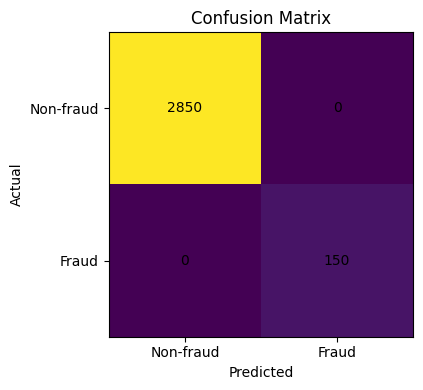

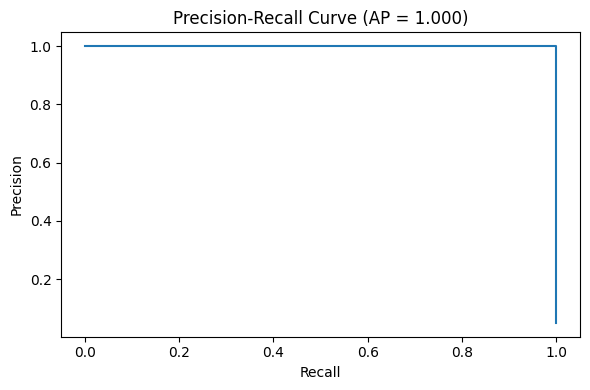

In [29]:
# Confusion matrix
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title('Confusion Matrix')
plt.xticks([0, 1], ['Non-fraud', 'Fraud'])
plt.yticks([0, 1], ['Non-fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=200)
plt.show()

# Precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(recall, precision)
plt.title(f'Precision-Recall Curve (AP = {ap:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'precision_recall_curve.png', dpi=200)
plt.show()

In [30]:
# Feature importance
preprocessor = model.named_steps['preprocess']
classifier = model.named_steps['classifier']
feature_names = list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)) + numeric_features
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': classifier.feature_importances_
}).sort_values('Importance', ascending=False)

importance_df.to_csv(OUTPUT_DIR / 'feature_importance.csv', index=False)
importance_df.head(15)

,Feature,Importance
21,device_risk_score,0.378395
22,ip_risk_score,0.277241
20,log_amount,0.136548
19,amount,0.135011
9,hour_bucket_Night (00-05),0.038248
2,country_NG,0.022284
7,hour_bucket_Evening (18-23),0.003192
6,hour_bucket_Afternoon (12-17),0.002943
8,hour_bucket_Morning (06-11),0.002809
1,country_FR,0.000697


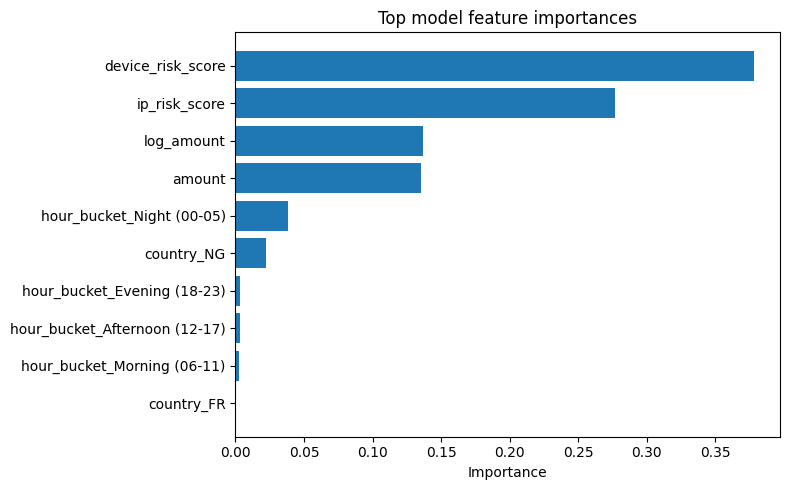

In [31]:
top_importance = importance_df.head(10).iloc[::-1]
plt.figure(figsize=(8, 5))
plt.barh(top_importance['Feature'], top_importance['Importance'])
plt.title('Top model feature importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=200)
plt.show()

## 8. Final findings

1. **Country and hour bucket are significantly associated with fraud** based on chi-square tests.
2. **Fraud transactions have higher average amount, device risk score and IP risk score** based on Welch t-tests.
3. **Device and IP risk scores differ across country and hour bucket groups** based on ANOVA.
4. **NG and Night transactions drive the main country/time risk-score differences** based on post-ANOVA follow-up tests.
5. **Device risk score and IP risk score are the strongest model drivers**, aligning with the statistical tests.

**Limitation:** The dataset is synthetic and has very clean signals. Real fraud data is usually noisier and should be validated on future time periods before operational use.